###Load and Preprocess Data

In [14]:
from pyspark.sql import SparkSession
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import col, abs
import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("TrafficFlowPrediction").getOrCreate()

df = spark.read.csv("/content/PEMS03.csv", header=True, inferSchema=True)

df = df.fillna(0)
assembler = VectorAssembler(inputCols=["speed", "flow", "occupancy"], outputCol="features")
df = assembler.transform(df).select("features", col("occupancy").alias("label"))

train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

##Correlation

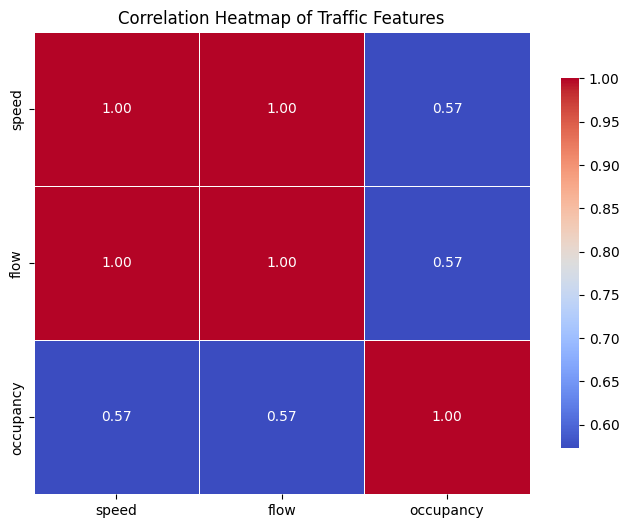

In [15]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col
import seaborn as sns
import matplotlib.pyplot as plt

# Extract individual features from the 'features' column
df_expanded = df.withColumn("speed", vector_to_array("features").getItem(0)) \
                 .withColumn("flow", vector_to_array("features").getItem(1)) \
                 .withColumn("occupancy", vector_to_array("features").getItem(2))

# Now you can select these extracted columns
df_pd = df_expanded.select("speed", "flow", "occupancy").toPandas()

# Compute the correlation matrix
correlation_matrix = df_pd.corr()

# Plot Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap of Traffic Features")
plt.show()

##Evaluation and Visualization Function

In [16]:
from pyspark.sql.functions import col, abs, when, lit

def evaluate_and_visualize(model, model_name, train_data, test_data):
    """
    This function fits a given regression model, makes predictions on the test data,
    evaluates performance using multiple regression metrics, and visualizes the results.
    """

    fitted_model = model.fit(train_data)

    predictions = fitted_model.transform(test_data)

    # Initialize evaluators
    evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
    evaluator_mse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mse")
    evaluator_mae = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
    evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

    # Calculate metrics
    rmse = evaluator_rmse.evaluate(predictions)
    mse = evaluator_mse.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)

    # Calculate MAPE, handling division by zero for label=0
    predictions = predictions.withColumn(
        "ape",
        when(col("label") == 0,
             when(col("prediction") == 0, 0)
             .otherwise(lit(None))) # Set APE to None if label is 0 and prediction is not 0
        .otherwise(abs((col("label") - col("prediction")) / col("label")))
    )

    # Filter out null APE values before averaging
    non_null_ape_predictions = predictions.filter(col("ape").isNotNull())
    mape = non_null_ape_predictions.agg({"ape": "avg"}).collect()[0][0] * 100 if non_null_ape_predictions.count() > 0 else 0

    # Print evaluation metrics
    print(f"{model_name} - Root Mean Squared Error (RMSE): {rmse}")
    print(f"{model_name} - Mean Squared Error (MSE): {mse}")
    print(f"{model_name} - Mean Absolute Error (MAE): {mae}")
    print(f"{model_name} - R-squared (R2): {r2}")
    print(f"{model_name} - Mean Absolute Percentage Error (MAPE): {mape}%")

    # Convert predictions to Pandas DataFrame for visualization
    predictions_pd = predictions.select("label", "prediction").toPandas()

    # Plot true vs predicted values
    plt.figure(figsize=(8, 6))
    plt.scatter(predictions_pd["label"], predictions_pd["prediction"], alpha=0.3, label=model_name, color="blue")
    plt.plot([
        predictions_pd["label"].min() if not predictions_pd["label"].empty else 0,
        predictions_pd["label"].max() if not predictions_pd["label"].empty else 0
    ],
             [
        predictions_pd["label"].min() if not predictions_pd["label"].empty else 0,
        predictions_pd["label"].max() if not predictions_pd["label"].empty else 0
    ], color="red", linestyle="--")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{model_name} - Predictions vs True Values")
    plt.legend()
    plt.show()

##Model Training and Evaluation

Linear Regression - Root Mean Squared Error (RMSE): 2.7897010049493124e-16
Linear Regression - Mean Squared Error (MSE): 7.782431697015204e-32
Linear Regression - Mean Absolute Error (MAE): 1.4239817054974833e-16
Linear Regression - R-squared (R2): 1.0
Linear Regression - Mean Absolute Percentage Error (MAPE): 2.4169013703920317e-14%


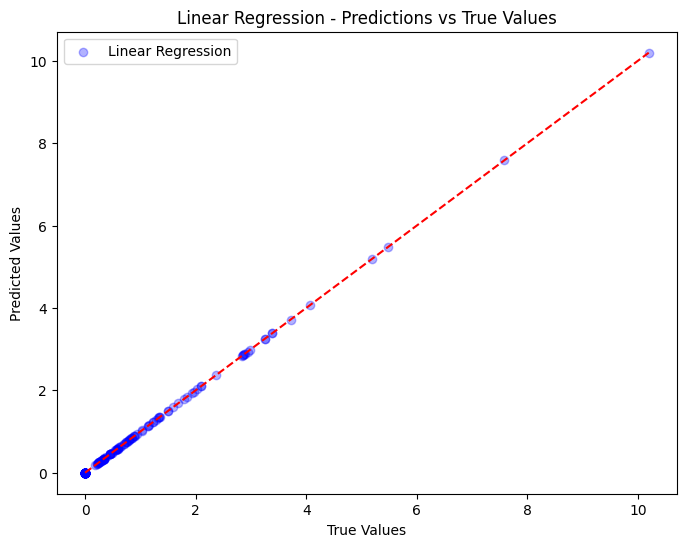

Decision Tree Regression - Root Mean Squared Error (RMSE): 0.4512862806478414
Decision Tree Regression - Mean Squared Error (MSE): 0.20365930710096225
Decision Tree Regression - Mean Absolute Error (MAE): 0.08796334582536122
Decision Tree Regression - R-squared (R2): 0.8857373505136301
Decision Tree Regression - Mean Absolute Percentage Error (MAPE): 4.050300150472145%


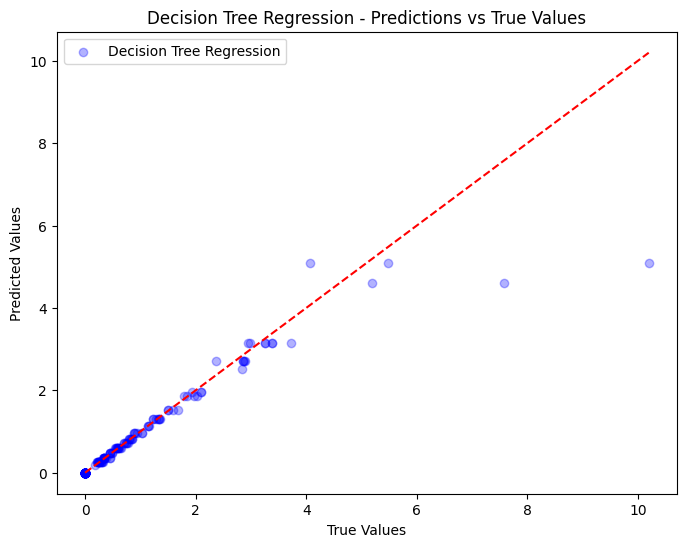

Random Forest Regression - Root Mean Squared Error (RMSE): 0.5066372794326621
Random Forest Regression - Mean Squared Error (MSE): 0.25668133291092937
Random Forest Regression - Mean Absolute Error (MAE): 0.15429226349162012
Random Forest Regression - R-squared (R2): 0.8559894483115563
Random Forest Regression - Mean Absolute Percentage Error (MAPE): 19.60364005258462%


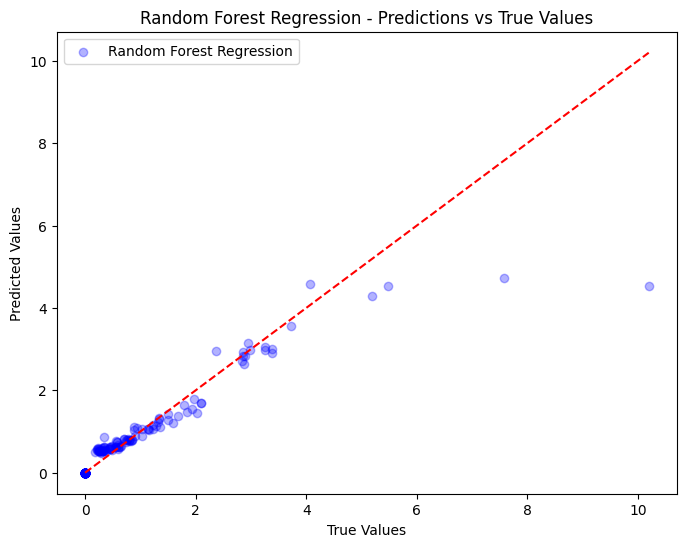

In [17]:
lr = LinearRegression(featuresCol="features", labelCol="label")
evaluate_and_visualize(lr, "Linear Regression", train_data, test_data)

# Decision Tree Regression
dt = DecisionTreeRegressor(featuresCol="features", labelCol="label")
evaluate_and_visualize(dt, "Decision Tree Regression", train_data, test_data)

# Random Forest Regression
rf = RandomForestRegressor(featuresCol="features", labelCol="label")
evaluate_and_visualize(rf, "Random Forest Regression", train_data, test_data)

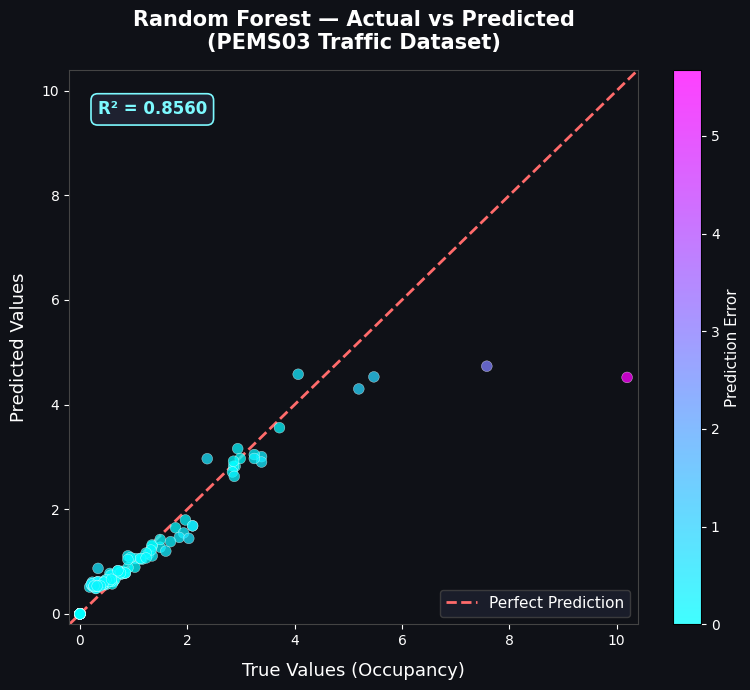

✅ Random Forest R² Score: 0.8560


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# --- Train and get predictions (matches your existing pattern) ---
rf = RandomForestRegressor(featuresCol="features", labelCol="label")
rf_model = rf.fit(train_data)
predictions = rf_model.transform(test_data)
predictions_pd = predictions.select("label", "prediction").toPandas()

# Sample 200 points for a clean plot
sample = predictions_pd.sample(n=min(200, len(predictions_pd)), random_state=42)
true_vals = sample["label"].values
pred_vals = sample["prediction"].values

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

# Perfect prediction diagonal
lims = [min(true_vals.min(), pred_vals.min()) - 0.2,
        max(true_vals.max(), pred_vals.max()) + 0.2]
ax.plot(lims, lims, '--', color='#FF6B6B', linewidth=2,
        label='Perfect Prediction', zorder=2)

# Scatter — color = error magnitude
scatter = ax.scatter(
    true_vals, pred_vals,
    c=np.abs(true_vals - pred_vals),
    cmap='cool',
    alpha=0.75,
    edgecolors='white',
    linewidths=0.3,
    s=60,
    zorder=3
)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Prediction Error', color='white', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# Labels & title
ax.set_xlabel("True Values (Occupancy)", fontsize=13, color='white', labelpad=10)
ax.set_ylabel("Predicted Values", fontsize=13, color='white', labelpad=10)
ax.set_title("Random Forest — Actual vs Predicted\n(PEMS03 Traffic Dataset)",
             fontsize=15, color='white', fontweight='bold', pad=15)

# R² annotation
r2 = r2_score(true_vals, pred_vals)
ax.text(0.05, 0.92, f"R² = {r2:.4f}", transform=ax.transAxes,
        fontsize=12, color='#7DF9FF', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#1e2130',
                  edgecolor='#7DF9FF', linewidth=1.2))

# Styling
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend(fontsize=11, facecolor='#1e2130', edgecolor='#444', labelcolor='white')

plt.tight_layout()
plt.savefig("actual_vs_predicted_rf.png", dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Random Forest R² Score: {r2:.4f}")

##Classification

In [19]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import col, when
import pandas as pd
import matplotlib.pyplot as plt

df = spark.read.csv("/content/PEMS03.csv", header=True, inferSchema=True)

df = df.fillna(0)

# Create categorical labels for occupancy levels within the range of 0 to 5.5
df = df.withColumn("label",
                   when(col("occupancy") < 2, 0).
                   when((col("occupancy") >= 2) & (col("occupancy") < 4), 1).
                   when((col("occupancy") >= 4) & (col("occupancy") <= 5.5), 2).
                   otherwise(None))  # Filter out values beyond 5.5 if necessary

# Prepare features
assembler = VectorAssembler(inputCols=["speed", "flow", "occupancy"], outputCol="features")
df = assembler.transform(df).select("features", "label")

# Filter any remaining rows without a label (if occupancy was above 5.5)
df = df.na.drop(subset=["label"])

# Split data into training and test sets
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

Logistic Regression - Accuracy: 1.0
Logistic Regression - Precision: 1.0
Logistic Regression - Recall: 1.0
Logistic Regression - F1-Score: 1.0
Logistic Regression - ROC-AUC: 1.0


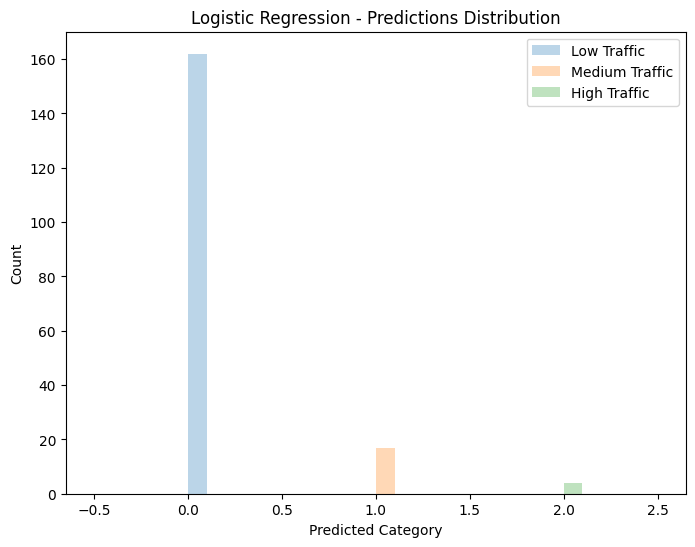

Decision Tree Classifier - Accuracy: 0.9726775956284153
Decision Tree Classifier - Precision: 0.9737216224621263
Decision Tree Classifier - Recall: 0.9726775956284153
Decision Tree Classifier - F1-Score: 0.9681834073265231
Decision Tree Classifier - ROC-AUC: 0.9523809523809523


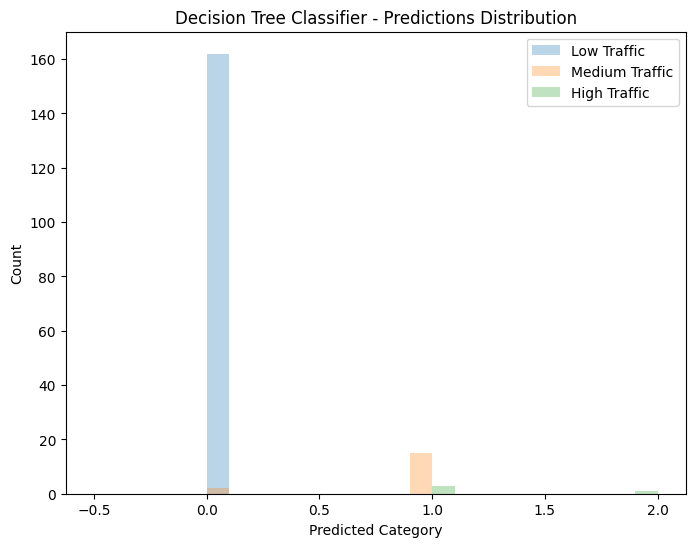

Random Forest Classifier - Accuracy: 0.9836065573770492
Random Forest Classifier - Precision: 0.9860655737704918
Random Forest Classifier - Recall: 0.9836065573770492
Random Forest Classifier - F1-Score: 0.9793531236154186
Random Forest Classifier - ROC-AUC: 1.0


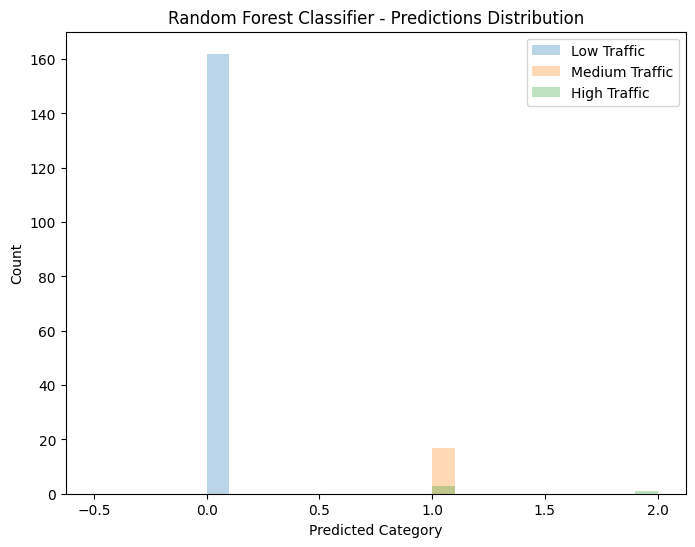

In [20]:
def evaluate_and_visualize(model, model_name, train_data, test_data):
    """
    This function fits a given classification model, makes predictions on the test data,
    evaluates performance using classification metrics, and visualizes results.
    """
    # Fit the model
    fitted_model = model.fit(train_data)

    # Make predictions
    predictions = fitted_model.transform(test_data)

    # Initialize evaluators
    evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
    evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
    evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
    evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
    evaluator_roc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="prediction", metricName="areaUnderROC")

    # Calculate metrics
    accuracy = evaluator_accuracy.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall = evaluator_recall.evaluate(predictions)
    f1 = evaluator_f1.evaluate(predictions)
    roc_auc = evaluator_roc.evaluate(predictions)

    # Print evaluation metrics
    print(f"{model_name} - Accuracy: {accuracy}")
    print(f"{model_name} - Precision: {precision}")
    print(f"{model_name} - Recall: {recall}")
    print(f"{model_name} - F1-Score: {f1}")
    print(f"{model_name} - ROC-AUC: {roc_auc}")

    # Visualization
    predictions_pd = predictions.select("label", "prediction").toPandas()
    plt.figure(figsize=(8, 6))
    plt.hist(predictions_pd[predictions_pd["label"] == 0]["prediction"], alpha=0.3, label="Low Traffic")
    plt.hist(predictions_pd[predictions_pd["label"] == 1]["prediction"], alpha=0.3, label="Medium Traffic")
    plt.hist(predictions_pd[predictions_pd["label"] == 2]["prediction"], alpha=0.3, label="High Traffic")
    plt.xlabel("Predicted Category")
    plt.ylabel("Count")
    plt.title(f"{model_name} - Predictions Distribution")
    plt.legend()
    plt.show()

# Logistic Regression
lr = LogisticRegression(featuresCol="features", labelCol="label")
evaluate_and_visualize(lr, "Logistic Regression", train_data, test_data)

# Decision Tree Classifier
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")
evaluate_and_visualize(dt, "Decision Tree Classifier", train_data, test_data)

# Random Forest Classifier
rf = RandomForestClassifier(featuresCol="features", labelCol="label")
evaluate_and_visualize(rf, "Random Forest Classifier", train_data, test_data)